Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported
   Device: cuda
   GPU: Tesla T4
   ✅ chanel_fake: 363 images
   ✅ chanel_real: 517 images
   ✅ coach_fake: 388 images
   ✅ coach_real: 560 images
   ✅ louisvuitton_fake: 54 images
   ✅ louisvuitton_real: 396 images
   ✅ ysl_fake: 592 images
   ✅ ysl_real: 410 images
   ✅ prada_fake: 527 images
   ✅ prada_real: 509 images
   ✅ fendi_fake: 305 images
   ✅ fendi_real: 417 images

📊 Summary (No Background Images — All Brands):
   Total images  : 5038
   Total products: 1075
   Chanel         : 188 products  (Fake=94  Real=94)
   Coach          : 188 products  (Fake=94  Real=94)
   Louis Vuitton  : 141 products  (Fake=47  Real=94)
   YSL            : 191 products  (Fake=96  Real=95)
   Prada          : 188 products  (Fake=94  Real=94)
   Fendi          : 179 products  (Fake=86  Real=93)
✅ Dataset class & transforms defined
✅ EfficientNet-B0: 

,Fold,Accuracy,Precision,Recall,F1,AUC
0,1,0.9209,0.8750,0.9912,0.9295,0.9728
1,2,0.9070,0.8760,0.9550,0.9138,0.9737
2,3,0.9070,0.8615,0.9825,0.9180,0.9681
3,4,0.8791,0.8271,0.9735,0.8943,0.9584
4,5,0.9302,0.9224,0.9469,0.9345,0.9599



📊 PER-BRAND BREAKDOWN (5-Fold Aggregate)

Brand                   Acc     Prec      Rec       F1      AUC      N
────────────────────────────────────────────────────────────────────
  Chanel             0.9149   0.8545   1.0000   0.9216   0.9771    188
  Coach              0.9309   0.9091   0.9574   0.9326   0.9780    188
  Louis Vuitton      0.8440   0.8333   0.9574   0.8911   0.9031    141
  YSL                0.9005   0.8725   0.9368   0.9036   0.9552    191
  Prada              0.9309   0.8932   0.9787   0.9340   0.9852    188
  Fendi              0.9162   0.8679   0.9892   0.9246   0.9702    179


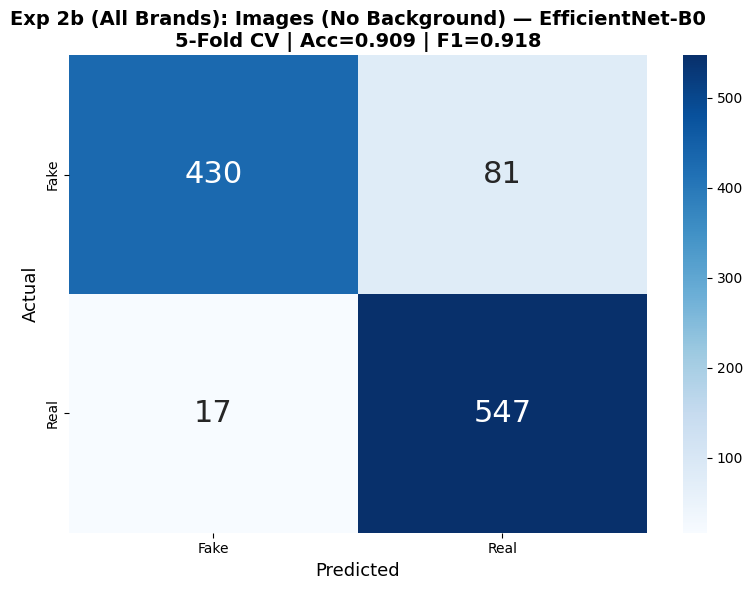

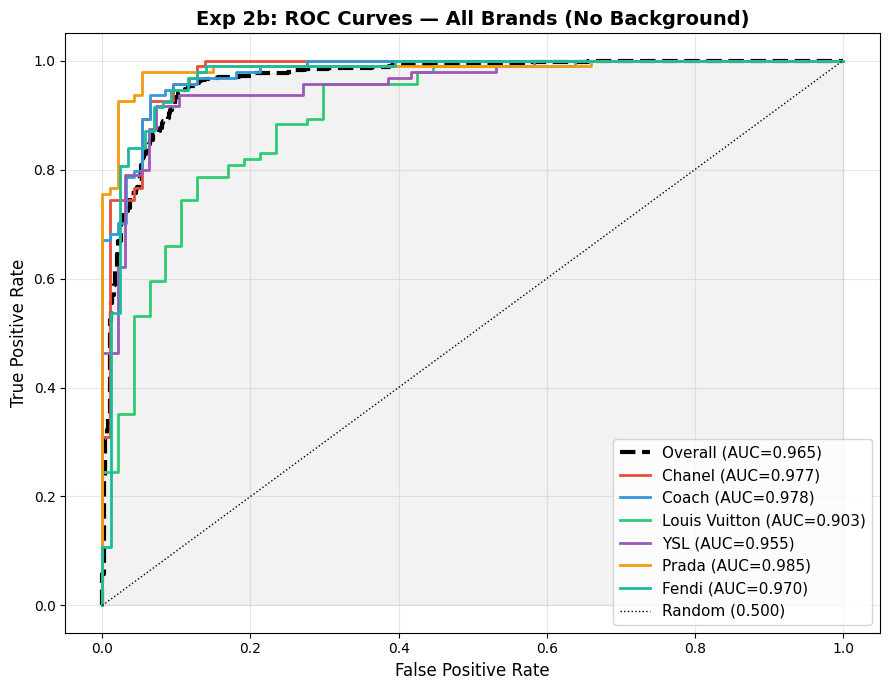

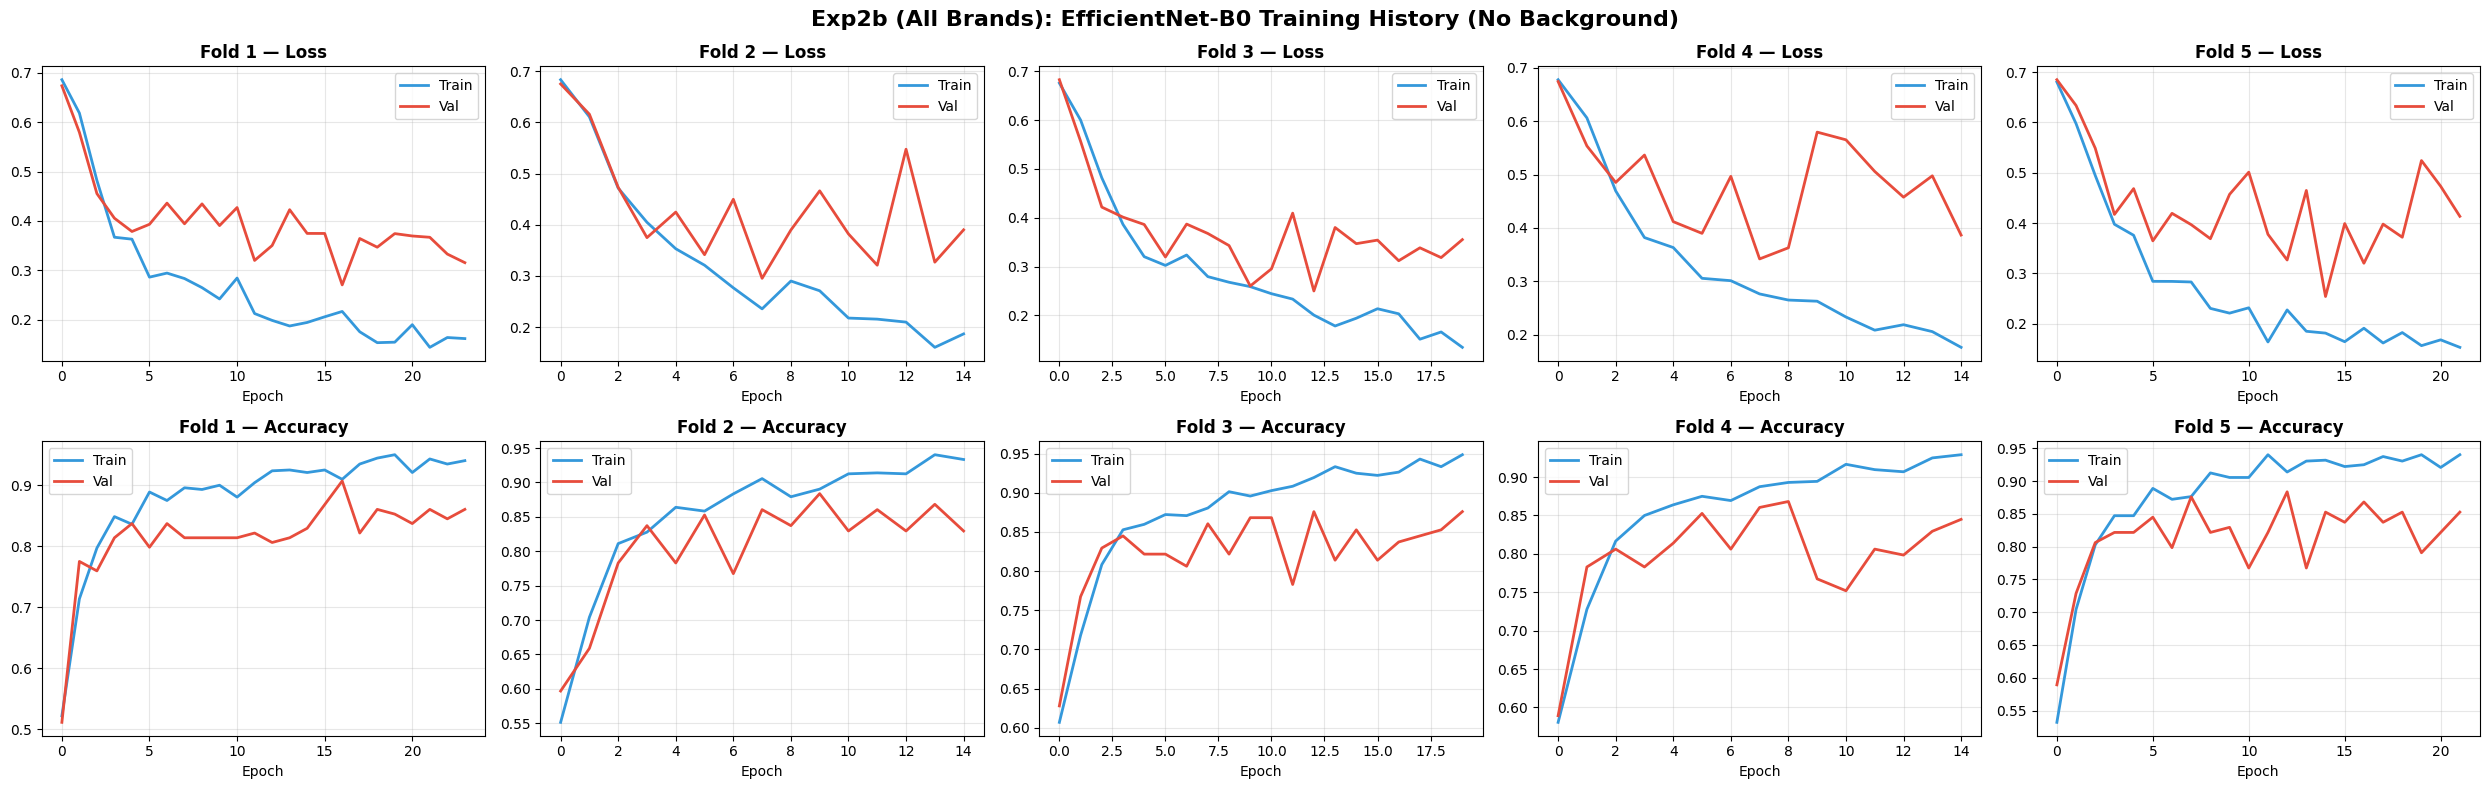

✅ Saved: exp2b_allbrands_training_history.png

✅ FILES SAVED:
   📊 exp2b_allbrands_results.csv / .xlsx
   🖼️ exp2b_allbrands_confusion_matrix.png
   🖼️ exp2b_allbrands_roc_curve.png
   🖼️ exp2b_allbrands_training_history.png

🎉 EXPERIMENT 2b (ALL BRANDS) COMPLETE!

📊 Overall: Acc=0.9088  F1=0.9180  AUC=0.9666


In [ ]:
# -*- coding: utf-8 -*-
"""بدون خلفيه.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1S-iXi8BieOJeUE3UyIUzMpiij5J01J0s
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries imported")
print(f"   Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


# ════════════════════════════════════════════════════════════
# الخلية 2: تحميل الصور (بدون خلفية) — كل البراندات
# ════════════════════════════════════════════════════════════

BASE = '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/'

# ─── المجلدات لكل البراندات ───
folders = {
    'chanel_fake':        os.path.join(BASE, 'Chanel/replica_nobg_chanel'),
    'chanel_real':        os.path.join(BASE, 'Chanel/original_nobg_chanel'),
    'coach_fake':         os.path.join(BASE, 'صور كوتش/replica_nobg_coach'),
    'coach_real':         os.path.join(BASE, 'صور كوتش/original_nobg_coach'),
    'louisvuitton_fake':  os.path.join(BASE, 'Louis Vuitton/replica_nobg_lv'),
    'louisvuitton_real':  os.path.join(BASE, 'Louis Vuitton/original_nobg_lv'),
    'ysl_fake':           os.path.join(BASE, 'YSL/replica_nobg_ysl'),
    'ysl_real':           os.path.join(BASE, 'YSL/original_nobg_ysl'),
    'prada_fake':         os.path.join(BASE, 'prada/replica_nobg_prada'),
    'prada_real':         os.path.join(BASE, 'prada/real_nobg_prada'),
    'fendi_fake':         os.path.join(BASE, 'fendi/replica_nobg_fendi'),
    'fendi_real':         os.path.join(BASE, 'fendi/real_nobg_fendi'),
}

def get_brand(key):
    if 'chanel' in key:       return 'Chanel'
    if 'coach' in key:        return 'Coach'
    if 'louisvuitton' in key: return 'Louis Vuitton'
    if 'ysl' in key:          return 'YSL'
    if 'prada' in key:        return 'Prada'
    if 'fendi' in key:        return 'Fendi'

image_data = []

for key, folder_path in folders.items():
    brand = get_brand(key)
    is_authentic = 1 if 'real' in key else 0

    if not os.path.exists(folder_path):
        print(f"⚠️ Folder not found: {folder_path}")
        continue

    files = sorted([f for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])

    for f in files:
        filepath = os.path.join(folder_path, f)
        parts = f.replace('.jpg','').replace('.jpeg','').replace('.png','').replace('.webp','').split('_')

        product_id = None
        for p in parts:
            try:
                num = int(p)
                if product_id is None:
                    product_id = num
            except:
                continue
        if product_id is None:
            product_id = f

        image_data.append({
            'filepath':     filepath,
            'filename':     f,
            'product_id':   f"{brand}_{is_authentic}_{product_id}",
            'brand':        brand,
            'is_authentic': is_authentic,
        })

    print(f"   ✅ {key}: {len(files)} images")

df_images = pd.DataFrame(image_data)

product_groups = df_images.groupby('product_id').agg({
    'filepath':     list,
    'is_authentic': 'first',
    'brand':        'first',
}).reset_index()

print(f"\n📊 Summary (No Background Images — All Brands):")
print(f"   Total images  : {len(df_images)}")
print(f"   Total products: {len(product_groups)}")
for brand in ['Chanel', 'Coach', 'Louis Vuitton', 'YSL', 'Prada', 'Fendi']:
    b = product_groups[product_groups['brand'] == brand]
    print(f"   {brand:<15}: {len(b)} products  "
          f"(Fake={len(b[b['is_authentic']==0])}  Real={len(b[b['is_authentic']==1])})")


# ════════════════════════════════════════════════════════════
# الخلية 3: Dataset Class
# ════════════════════════════════════════════════════════════

class BagImageDataset(Dataset):
    def __init__(self, product_ids, labels, image_paths_dict, transform=None):
        self.product_ids      = product_ids
        self.labels           = labels
        self.image_paths_dict = image_paths_dict
        self.transform        = transform

    def __len__(self):
        return len(self.product_ids)

    def __getitem__(self, idx):
        pid   = self.product_ids[idx]
        label = self.labels[idx]
        paths = self.image_paths_dict[pid]
        img_path = paths[np.random.randint(len(paths))]

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✅ Dataset class & transforms defined")


# ════════════════════════════════════════════════════════════
# الخلية 4: بناء EfficientNet-B0
# ════════════════════════════════════════════════════════════

def create_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[-3:].parameters():
        param.requires_grad = True
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(1280, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )
    return model

model_test = create_efficientnet()
trainable = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_test.parameters())
print(f"✅ EfficientNet-B0: {trainable:,} trainable / {total:,} total ({trainable/total*100:.1f}%)")
del model_test


# ════════════════════════════════════════════════════════════
# الخلية 5: دوال التدريب والتقييم
# ════════════════════════════════════════════════════════════

def train_image_model(model, train_loader, val_loader, epochs=30, patience=7, lr=0.0001):
    criterion = nn.BCELoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss  = float('inf')
    best_state     = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images).squeeze(-1)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item()
            t_correct += ((outputs >= 0.5).float() == labels).sum().item()
            t_total   += len(labels)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs  = model(images).squeeze(-1)
                v_loss  += criterion(outputs, labels).item()
                v_correct += ((outputs >= 0.5).float() == labels).sum().item()
                v_total  += len(labels)

        avg_tl = t_loss / len(train_loader)
        avg_vl = v_loss / len(val_loader)
        t_acc  = t_correct / t_total
        v_acc  = v_correct / v_total

        history['train_loss'].append(avg_tl)
        history['val_loss'].append(avg_vl)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        scheduler.step(avg_vl)

        marker = ""
        if avg_vl < best_val_loss:
            best_val_loss    = avg_vl
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = " ✅"
        else:
            patience_counter += 1

        print(f"   Epoch {epoch+1:>2}/{epochs} | TrLoss:{avg_tl:.4f} VlLoss:{avg_vl:.4f} | TrAcc:{t_acc:.3f} VlAcc:{v_acc:.3f}{marker}")

        if patience_counter >= patience:
            print(f"   ⏹️ Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


def evaluate_image_model(model, test_loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for images, lbls in test_loader:
            images  = images.to(device)
            outputs = model(images).squeeze()
            preds.extend((outputs >= 0.5).float().cpu().numpy())
            probs.extend(outputs.cpu().numpy())
            labels.extend(lbls.numpy())
    return np.array(preds), np.array(probs), np.array(labels)

print("✅ Training functions defined")


# ════════════════════════════════════════════════════════════
# الخلية 6: 5-Fold CV — كل البراندات مجتمعين
# ════════════════════════════════════════════════════════════

N_FOLDS    = 5
EPOCHS     = 30
BATCH_SIZE = 16

product_ids    = product_groups['product_id'].values
product_labels = product_groups['is_authentic'].values
product_brands = product_groups['brand'].values
stratify_col   = [f"{b}_{l}" for b, l in zip(product_brands, product_labels)]

image_paths_dict = dict(zip(product_groups['product_id'], product_groups['filepath']))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_fold_results = []
all_true, all_pred, all_prob = [], [], []
fold_histories = []
best_states    = []

print(f"🚀 Starting {N_FOLDS}-Fold CV (All Brands — No Background)")
print(f"   Products: {len(product_ids)} | Images: {len(df_images)}")
print("="*70)

for fold, (train_idx, test_idx) in enumerate(skf.split(product_ids, stratify_col)):
    print(f"\n{'═'*60}")
    print(f"📌 FOLD {fold+1}/{N_FOLDS}")
    print(f"{'═'*60}")

    train_pids   = product_ids[train_idx]
    test_pids    = product_ids[test_idx]
    train_labels = product_labels[train_idx]
    test_labels  = product_labels[test_idx]

    val_size          = int(0.15 * len(train_pids))
    val_pids          = train_pids[-val_size:]
    val_labels_split  = train_labels[-val_size:]
    train_pids_split  = train_pids[:-val_size]
    train_labels_split = train_labels[:-val_size]

    print(f"   Train: {len(train_pids_split)} | Val: {len(val_pids)} | Test: {len(test_pids)}")

    train_ds = BagImageDataset(train_pids_split, train_labels_split, image_paths_dict, train_transform)
    val_ds   = BagImageDataset(val_pids,         val_labels_split,   image_paths_dict, test_transform)
    test_ds  = BagImageDataset(test_pids,        test_labels,        image_paths_dict, test_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model, history = train_image_model(create_efficientnet().to(device), train_loader, val_loader, epochs=EPOCHS)
    fold_histories.append(history)

    fold_probs_list = []
    for _ in range(3):
        _, probs, _ = evaluate_image_model(model, test_loader)
        fold_probs_list.append(probs)

    avg_probs   = np.mean(fold_probs_list, axis=0)
    final_preds = (avg_probs >= 0.5).astype(float)

    acc  = accuracy_score(test_labels, final_preds)
    prec = precision_score(test_labels, final_preds, zero_division=0)
    rec  = recall_score(test_labels, final_preds, zero_division=0)
    f1   = f1_score(test_labels, final_preds, zero_division=0)
    auc  = roc_auc_score(test_labels, avg_probs)

    all_fold_results.append({'Fold': fold+1, 'Accuracy': acc, 'Precision': prec,
                             'Recall': rec, 'F1': f1, 'AUC': auc})
    all_true.extend(test_labels)
    all_pred.extend(final_preds)
    all_prob.extend(avg_probs)

    print(f"\n   📊 Fold {fold+1}: Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

    best_states.append({k: v.cpu().clone() for k, v in model.state_dict().items()})

    del model
    torch.cuda.empty_cache() if device.type == 'cuda' else None

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)

print(f"\n{'='*70}")
print("✅ All folds completed!")


# ════════════════════════════════════════════════════════════
# الخلية 7: جدول النتائج
# ════════════════════════════════════════════════════════════

fold_df = pd.DataFrame(all_fold_results)

print("\n" + "="*80)
print("📊 EXPERIMENT 2b: IMAGE (NO BG) — ALL BRANDS — RESULTS (5-Fold CV)")
print("="*80)

print(f"\n{'Fold':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print("─" * 60)
for _, row in fold_df.iterrows():
    print(f"{row['Fold']:>6.0f} {row['Accuracy']:>10.4f} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1']:>10.4f} {row['AUC']:>10.4f}")
print("─" * 60)
print(f"{'Mean':>6} {fold_df['Accuracy'].mean():>10.4f} {fold_df['Precision'].mean():>10.4f} {fold_df['Recall'].mean():>10.4f} {fold_df['F1'].mean():>10.4f} {fold_df['AUC'].mean():>10.4f}")
print(f"{'Std':>6}  {fold_df['Accuracy'].std():>10.4f} {fold_df['Precision'].std():>10.4f} {fold_df['Recall'].std():>10.4f} {fold_df['F1'].std():>10.4f} {fold_df['AUC'].std():>10.4f}")

display(fold_df.round(4))


# ════════════════════════════════════════════════════════════
# الخلية 8: نتائج لكل براند على حدة (Per-Brand Breakdown)
# ════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 PER-BRAND BREAKDOWN (5-Fold Aggregate)")
print("="*70)

# نجمع التوقعات مع معلومة البراند
all_true_arr  = np.array(all_true)
all_pred_arr  = np.array(all_pred)
all_prob_arr  = np.array(all_prob)

# نحتاج نعرف براند كل product في test — نبنيه من skf
brand_per_test = []
for fold, (train_idx, test_idx) in enumerate(skf.split(product_ids, stratify_col)):
    test_pids = product_ids[test_idx]
    for pid in test_pids:
        b = product_groups[product_groups['product_id'] == pid]['brand'].values[0]
        brand_per_test.append(b)

brand_per_test = np.array(brand_per_test)

print(f"\n{'Brand':<18} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8} {'N':>6}")
print("─" * 68)

for brand in ['Chanel', 'Coach', 'Louis Vuitton', 'YSL', 'Prada', 'Fendi']:
    mask = brand_per_test == brand
    if mask.sum() == 0:
        continue
    bt = all_true_arr[mask]
    bp = all_pred_arr[mask]
    bprob = all_prob_arr[mask]
    try:
        auc_b = roc_auc_score(bt, bprob)
    except:
        auc_b = float('nan')
    print(f"  {brand:<16} {accuracy_score(bt,bp):>8.4f} "
          f"{precision_score(bt,bp,zero_division=0):>8.4f} "
          f"{recall_score(bt,bp,zero_division=0):>8.4f} "
          f"{f1_score(bt,bp,zero_division=0):>8.4f} "
          f"{auc_b:>8.4f} {mask.sum():>6}")


# ════════════════════════════════════════════════════════════
# الخلية 9: Confusion Matrix
# ════════════════════════════════════════════════════════════

cm      = confusion_matrix(all_true, all_pred)
acc_all = accuracy_score(all_true, all_pred)
f1_all  = f1_score(all_true, all_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, annot_kws={'size': 22},
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
ax.set_ylabel('Actual', fontsize=13)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_title(f'Exp 2b (All Brands): Images (No Background) — EfficientNet-B0\n'
             f'5-Fold CV | Acc={acc_all:.3f} | F1={f1_all:.3f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exp2b_allbrands_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# الخلية 10: ROC Curve — كل البراندات + لكل براند
# ════════════════════════════════════════════════════════════

colors = {'Chanel': '#e74c3c', 'Coach': '#3498db', 'Louis Vuitton': '#2ecc71', 'YSL': '#9b59b6',
          'Prada': '#f39c12', 'Fendi': '#1abc9c'}

plt.figure(figsize=(9, 7))

# Overall
fpr_all, tpr_all, _ = roc_curve(all_true, all_prob)
auc_all = roc_auc_score(all_true, all_prob)
plt.plot(fpr_all, tpr_all, color='black', linewidth=3,
         label=f'Overall (AUC={auc_all:.3f})', linestyle='--')

# Per brand
for brand, color in colors.items():
    mask = brand_per_test == brand
    if mask.sum() == 0 or len(np.unique(all_true_arr[mask])) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(all_true_arr[mask], all_prob_arr[mask])
    auc_b = roc_auc_score(all_true_arr[mask], all_prob_arr[mask])
    plt.plot(fpr_b, tpr_b, color=color, linewidth=2, label=f'{brand} (AUC={auc_b:.3f})')

plt.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random (0.500)')
plt.fill_between(fpr_all, tpr_all, alpha=0.05, color='black')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Exp 2b: ROC Curves — All Brands (No Background)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp2b_allbrands_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# الخلية 11: Training History
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, N_FOLDS, figsize=(5*N_FOLDS, 8))
fig.suptitle('Exp2b (All Brands): EfficientNet-B0 Training History (No Background)',
             fontsize=16, fontweight='bold')

for fold_i, hist in enumerate(fold_histories):
    axes[0][fold_i].plot(hist['train_loss'], label='Train', color='#3498db', linewidth=2)
    axes[0][fold_i].plot(hist['val_loss'],   label='Val',   color='#e74c3c', linewidth=2)
    axes[0][fold_i].set_title(f'Fold {fold_i+1} — Loss', fontweight='bold')
    axes[0][fold_i].set_xlabel('Epoch')
    axes[0][fold_i].legend()
    axes[0][fold_i].grid(True, alpha=0.3)

    axes[1][fold_i].plot(hist['train_acc'], label='Train', color='#3498db', linewidth=2)
    axes[1][fold_i].plot(hist['val_acc'],   label='Val',   color='#e74c3c', linewidth=2)
    axes[1][fold_i].set_title(f'Fold {fold_i+1} — Accuracy', fontweight='bold')
    axes[1][fold_i].set_xlabel('Epoch')
    axes[1][fold_i].legend()
    axes[1][fold_i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2b_allbrands_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: exp2b_allbrands_training_history.png")


# ════════════════════════════════════════════════════════════
# الخلية 12: حفظ الملفات
# ════════════════════════════════════════════════════════════

fold_df.to_csv('exp2b_allbrands_results.csv',   index=False)
fold_df.to_excel('exp2b_allbrands_results.xlsx', index=False)

print("\n✅ FILES SAVED:")
print("   📊 exp2b_allbrands_results.csv / .xlsx")
print("   🖼️ exp2b_allbrands_confusion_matrix.png")
print("   🖼️ exp2b_allbrands_roc_curve.png")
print("   🖼️ exp2b_allbrands_training_history.png")

print("\n" + "="*60)
print("🎉 EXPERIMENT 2b (ALL BRANDS) COMPLETE!")
print("="*60)
print(f"\n📊 Overall: Acc={fold_df['Accuracy'].mean():.4f}  "
      f"F1={fold_df['F1'].mean():.4f}  AUC={fold_df['AUC'].mean():.4f}")